# From-Scratch Transformer for Text-to-SQL

Implementation and training of a Transformer-based Text-to-SQL model on the WikiSQL dataset.

### Project Overview

This project implements a Transformer encoder-decoder architecture from scratch for translating natural language questions and table schemas into SQL queries.

**Dataset:** WikiSQL  
**Model:** Transformer Encoder-Decoder  
**Tokenizer:** SentencePiece BPE  
**Training:** 20 epochs  
**Device:** CUDA  
**Trainable Parameters:** 7,585,600

In [1]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.11.0+cpu
Device: CPU


In [2]:
EPOCHS = 20
BATCH_SIZE = 64
D_MODEL = 256
WARMUP_STEPS = 4000
LABEL_SMOOTHING = 0.1

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Model dimension:", D_MODEL)
print("Warmup steps:", WARMUP_STEPS)
print("Label smoothing:", LABEL_SMOOTHING)

Epochs: 20
Batch size: 64
Model dimension: 256
Warmup steps: 4000
Label smoothing: 0.1


In [3]:
train_pairs = 56336
dev_pairs = 8421
skipped_train = 19

print(f"Training examples: {train_pairs:,}")
print(f"Development examples: {dev_pairs:,}")
print(f"Skipped training examples: {skipped_train}")

Training examples: 56,336
Development examples: 8,421
Skipped training examples: 19


In [4]:
results = [
    [1, 24.1997, 6.5175, 2.176536e-04],
    [2, 4.8522, 3.4653, 4.353073e-04],
    [3, 3.3461, 3.0005, 6.529609e-04],
    [4, 2.9686, 2.7298, 8.706146e-04],
    [5, 2.7224, 2.6015, 9.416881e-04],
    [6, 2.5486, 2.4765, 8.596396e-04],
    [7, 2.4177, 2.3736, 7.958717e-04],
    [8, 2.3178, 2.3317, 7.444698e-04],
    [9, 2.2380, 2.2586, 7.018928e-04],
    [10, 2.1685, 2.2186, 6.658740e-04],
    [11, 2.1092, 2.1886, 6.348860e-04],
    [12, 2.0613, 2.1535, 6.078570e-04],
    [13, 2.0175, 2.1370, 5.840101e-04],
    [14, 1.9801, 2.1222, 5.627663e-04],
    [15, 1.9483, 2.1247, 5.436839e-04],
    [16, 1.9193, 2.1145, 5.264196e-04],
    [17, 1.8940, 2.1033, 5.107021e-04],
    [18, 1.8714, 2.0871, 4.963132e-04],
    [19, 1.8492, 2.0844, 4.830758e-04],
    [20, 1.8308, 2.0897, 4.708440e-04],
]

results_df = pd.DataFrame(
    results,
    columns=["Epoch", "Train Loss", "Dev Loss", "Learning Rate"]
)

results_df

,Epoch,Train Loss,Dev Loss,Learning Rate
0,1,24.1997,6.5175,0.000218
1,2,4.8522,3.4653,0.000435
2,3,3.3461,3.0005,0.000653
3,4,2.9686,2.7298,0.000871
4,5,2.7224,2.6015,0.000942
5,6,2.5486,2.4765,0.000860
6,7,2.4177,2.3736,0.000796
7,8,2.3178,2.3317,0.000744
8,9,2.2380,2.2586,0.000702
9,10,2.1685,2.2186,0.000666


In [5]:
best_row = results_df.loc[results_df["Dev Loss"].idxmin()]

print("Best Epoch:", int(best_row["Epoch"]))
print("Best Dev Loss:", best_row["Dev Loss"])
print("Train Loss at Best Epoch:", best_row["Train Loss"])
print("Parameters:", "7,585,600")

Best Epoch: 19
Best Dev Loss: 2.0844
Train Loss at Best Epoch: 1.8492
Parameters: 7,585,600


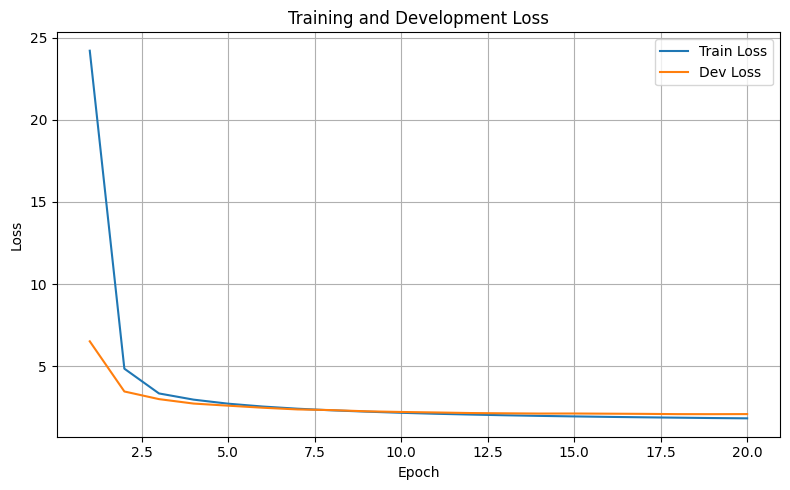

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Epoch"],
    results_df["Train Loss"],
    label="Train Loss"
)

plt.plot(
    results_df["Epoch"],
    results_df["Dev Loss"],
    label="Dev Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Development Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Saved Artifacts

The trained model and supporting artifacts were saved separately from the source code.

- `best.pt` — best trained Transformer checkpoint
- `sql_sp.model` — SentencePiece tokenizer model
- `sql_sp.vocab` — tokenizer vocabulary
- `training_results.csv` — epoch-wise training results
- `loss_curve.png` — training/development loss curve

The best checkpoint corresponds to **Epoch 19**, with a development loss of **2.0844**.